<a href="https://colab.research.google.com/github/AlexandreVenturini/visualizacao_de_dados_colab/blob/main/mini_projeto_3_visualizacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Projeto 3 — Análise Exploratória de Dados COVID-19

---

# 1. Introdução

Este projeto tem como objetivo realizar uma análise exploratória de dados relacionados à vacinação contra a COVID-19, utilizando técnicas de estatística básica, visualização de dados, análise temporal, identificação de padrões e criação de indicadores (KPIs).

O dataset utilizado contém informações sobre pacientes vacinados, incluindo idade, sexo biológico, fabricante da vacina, município de aplicação e data da vacinação. A análise foi desenvolvida utilizando Python no Google Colab, com apoio das bibliotecas Pandas, Matplotlib e Seaborn.

O principal objetivo da análise é identificar comportamentos relevantes nos dados, compreender padrões de vacinação ao longo do tempo e gerar insights a partir das informações disponíveis.

---

## 2. Importação das Bibliotecas

Nesta etapa foram importadas as bibliotecas necessárias para manipulação, análise e visualização dos dados utilizados no projeto.

As principais bibliotecas utilizadas foram:
- Pandas → manipulação e organização dos dados
- NumPy → operações numéricas
- Matplotlib → criação de gráficos
- Seaborn → visualização estatística dos dados
- Google Drive → acesso ao dataset armazenado na nuvem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

CAMINHO_ARQUIVO = '/content/drive/MyDrive/vacinacao_covid.csv'

Mounted at /content/drive


## 3. Carregamento e Descrição dos Dados

Nesta etapa foi realizado o carregamento do dataset contendo informações sobre vacinação contra a COVID-19.

Também foram analisadas características gerais da base de dados, como quantidade de registros, colunas, tipos de variáveis, valores ausentes e possíveis duplicidades.

In [2]:
def carregar_dados():
    colunas = [
        'paciente_id', 'paciente_idade', 'paciente_enumSexoBiologico',
        'vacina_nome', 'vacina_dataAplicacao', 'vacina_fabricante_nome',
        'estabelecimento_municipio_nome', 'vacina_descricao_dose'
    ]

    tipos = {
        'paciente_idade': 'float32',
        'paciente_enumSexoBiologico': 'category',
        'vacina_fabricante_nome': 'category'
    }

    df = pd.read_csv(
        CAMINHO_ARQUIVO,
        sep=';',
        usecols=colunas,
        dtype=tipos,
        nrows=550000
    )

    return df

df_bruto = carregar_dados()

print(f"Dataset carregado com {df_bruto.shape[0]} linhas.")

Dataset carregado com 550000 linhas.


### Informações Gerais do Dataset

In [3]:
print("\nQuantidade de registros:", df_bruto.shape[0])
print("Quantidade de colunas:", df_bruto.shape[1])

print("\nTipos de variáveis:")
print(df_bruto.dtypes)


Quantidade de registros: 550000
Quantidade de colunas: 8

Tipos de variáveis:
paciente_id                         object
paciente_idade                     float32
paciente_enumSexoBiologico        category
estabelecimento_municipio_nome      object
vacina_fabricante_nome            category
vacina_dataAplicacao                object
vacina_descricao_dose               object
vacina_nome                         object
dtype: object


### Verificação de Problemas nos Dados

Nesta etapa foram analisados possíveis problemas no dataset, incluindo:
- valores ausentes,
- registros duplicados,
- inconsistências nos dados.

In [4]:
print("\nValores ausentes:")
print(df_bruto.isnull().sum())

print("\nRegistros duplicados:", df_bruto.duplicated().sum())


Valores ausentes:
paciente_id                        3
paciente_idade                     3
paciente_enumSexoBiologico         3
estabelecimento_municipio_nome     0
vacina_fabricante_nome             0
vacina_dataAplicacao               0
vacina_descricao_dose              0
vacina_nome                       16
dtype: int64

Registros duplicados: 95


## 4. Tratamento e Limpeza dos Dados

Nesta etapa foram realizados procedimentos de limpeza e preparação do dataset, com o objetivo de melhorar a qualidade das análises realizadas posteriormente.

As principais ações executadas foram:
- remoção de registros duplicados;
- tratamento de valores ausentes;
- conversão e padronização de datas;
- remoção de idades inválidas;
- padronização de nomes de municípios;
- remoção de registros inconsistentes ou incompletos relacionados aos fabricantes das vacinas.

In [5]:
def processar_dados(df):
    df = df.drop_duplicates()

    df = df.dropna(subset=['paciente_idade', 'vacina_nome'])

    df['vacina_dataAplicacao'] = pd.to_datetime(
        df['vacina_dataAplicacao'],
        errors='coerce'
    )

    df = df.dropna(subset=['vacina_dataAplicacao'])

    df = df[df['vacina_dataAplicacao'].dt.year >= 2020]

    df['estabelecimento_municipio_nome'] = (
        df['estabelecimento_municipio_nome']
        .str.upper()
        .str.strip()
    )

    df['vacina_fabricante_nome'] = (
        df['vacina_fabricante_nome']
            .astype(str)
            .replace({
                'PFIZER - PEDI?TRICA': 'PFIZER - PEDIÁTRICA',
                'Pendente Identifica??o': 'Pendente Identificação'
            })
    )

    df = df[
        (df['paciente_idade'] >= 0) &
        (df['paciente_idade'] <= 115)
    ]

    df['mes_aplicacao'] = df['vacina_dataAplicacao'].dt.month

    return df


df_limpo = processar_dados(df_bruto)

print(f"Limpeza concluída! Total de registros após tratamento: {df_limpo.shape[0]}")

Limpeza concluída! Total de registros após tratamento: 549881


### Medidas de Tendência Central e Dispersão

Nesta etapa foram calculadas medidas estatísticas relacionadas à idade dos pacientes vacinados, com o objetivo de compreender o comportamento geral da distribuição dos dados.

Foram analisadas medidas de tendência central, como média, mediana e moda, além de medidas de dispersão, como variância, desvio padrão e amplitude.

Essas métricas permitem identificar padrões nas idades dos pacientes, verificar a existência de valores extremos e avaliar o nível de dispersão presente no dataset.

In [6]:
idades = df_limpo['paciente_idade'].dropna()

idades = idades[(idades >= 0) & (idades <= 120)]

print("Quantidade de idades válidas:", len(idades))

print("\nMédia:", idades.mean())
print("Mediana:", idades.median())
print("Moda:", idades.mode()[0])

print("\nVariância:", idades.var())
print("Desvio padrão:", idades.std())

print("\nIdade mínima:", idades.min())
print("Idade máxima:", idades.max())

print("Amplitude:", idades.max() - idades.min())

Quantidade de idades válidas: 549881

Média: 42.14443
Mediana: 42.0
Moda: 39.0

Variância: 452.41510009765625
Desvio padrão: 21.270051956176758

Idade mínima: 0.0
Idade máxima: 113.0
Amplitude: 113.0


### Interpretação dos Resultados

A análise estatística das idades mostrou que a média (42,14) e a mediana (42) apresentaram valores muito próximos, indicando uma distribuição relativamente equilibrada dos dados.

A moda identificada foi 39 anos, representando a idade mais frequente no dataset. O desvio padrão de aproximadamente 21 anos demonstra uma dispersão considerável nas idades dos pacientes vacinados.

Também foi possível observar valores extremos, com idades variando entre 0 e 113 anos, resultando em uma amplitude total de 113 anos.

## 6. Visualização dos Dados

Nesta etapa foram utilizados gráficos estatísticos para analisar o comportamento dos dados, identificar padrões, tendências e possíveis valores extremos relacionados à vacinação contra a COVID-19.

### Histograma das Idades dos Pacientes

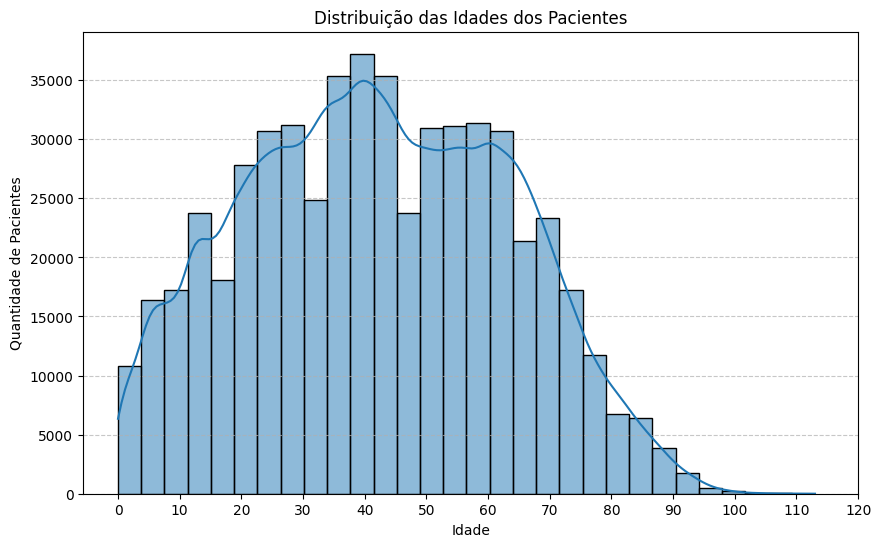

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    idades,
    bins=30,
    kde=True
)

plt.title('Distribuição das Idades dos Pacientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade de Pacientes')

plt.xticks(range(0, 121, 10))

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Interpretação do Histograma

O histograma demonstrou a distribuição das idades dos pacientes vacinados, evidenciando maior concentração de indivíduos entre aproximadamente 30 e 70 anos.

Também foi possível observar redução gradual da quantidade de pacientes em idades mais elevadas, além da presença de alguns valores extremos acima dos 100 anos.

### Boxplot das Idades por Sexo

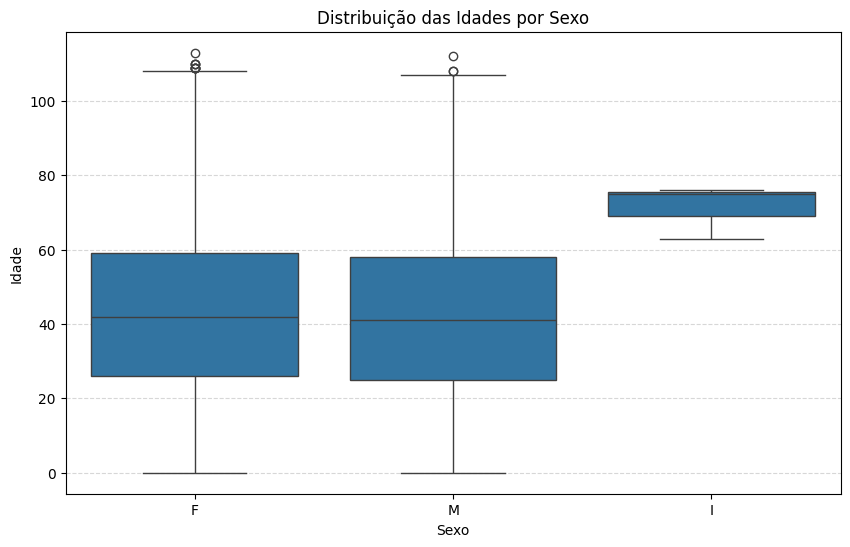

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_limpo,
    x='paciente_enumSexoBiologico',
    y='paciente_idade'
)

plt.title('Distribuição das Idades por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Idade')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Interpretação do Boxplot

O boxplot permitiu analisar a distribuição das idades entre os sexos biológicos presentes no dataset.

Os grupos masculino e feminino apresentaram distribuições semelhantes, com medianas próximas e ampla dispersão das idades.

Também foi identificado o grupo “I”, correspondente a pacientes com sexo biológico indefinido ou não informado. Esse grupo apresentou menor quantidade de registros e menor dispersão quando comparado aos demais.

Além disso, foram observados possíveis outliers relacionados a pacientes com idades muito elevadas, acima de 100 anos.

### Scatterplot — Idade dos Pacientes ao Longo do Tempo


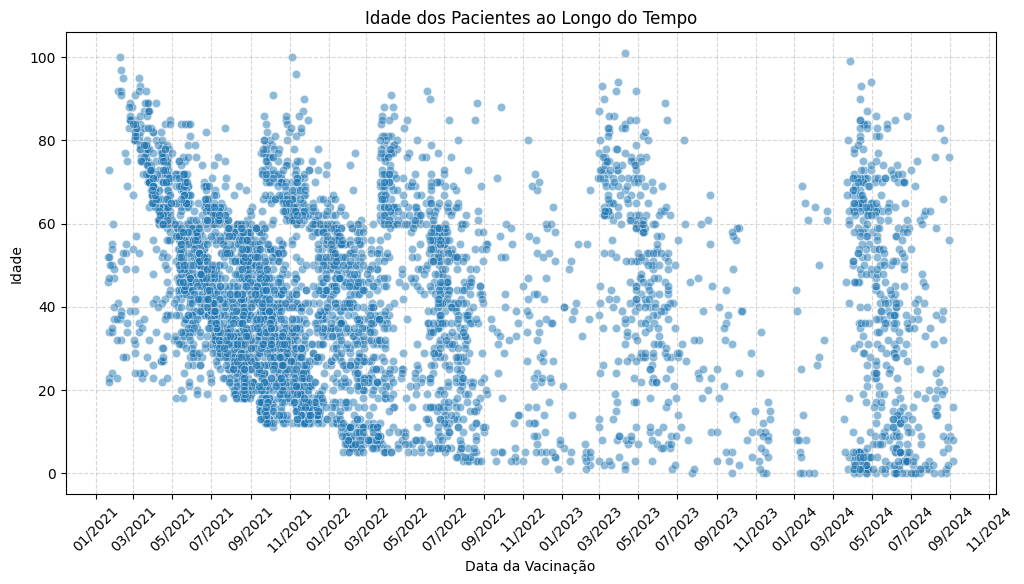

In [9]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df_limpo.sample(5000),
    x='vacina_dataAplicacao',
    y='paciente_idade',
    alpha=0.5
)

plt.title('Idade dos Pacientes ao Longo do Tempo')
plt.xlabel('Data da Vacinação')
plt.ylabel('Idade')

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%m/%Y')
)

plt.xticks(rotation=45)

plt.grid(linestyle='--', alpha=0.5)

plt.show()

### Interpretação do Scatterplot

O scatterplot permitiu visualizar a relação entre a idade dos pacientes e o período de aplicação das vacinas ao longo do tempo.

Foi possível identificar que pacientes com idades mais elevadas apareceram com maior frequência nos períodos iniciais da campanha de vacinação, enquanto faixas etárias mais jovens passaram a surgir com maior intensidade nos períodos posteriores.

Esse comportamento acompanha a estratégia de vacinação adotada durante a pandemia, na qual grupos prioritários, como idosos, receberam as primeiras doses antes das demais faixas etárias.

### Agrupamento Temporal dos Dados

Nesta etapa os dados foram agrupados por data de aplicação da vacina, permitindo analisar a quantidade de vacinações realizadas ao longo do tempo.

In [10]:
vacinas_por_dia = (
    df_limpo
    .groupby('vacina_dataAplicacao')
    .size()
)

### Gráfico Temporal — Quantidade de Vacinas Aplicadas ao Longo do Tempo

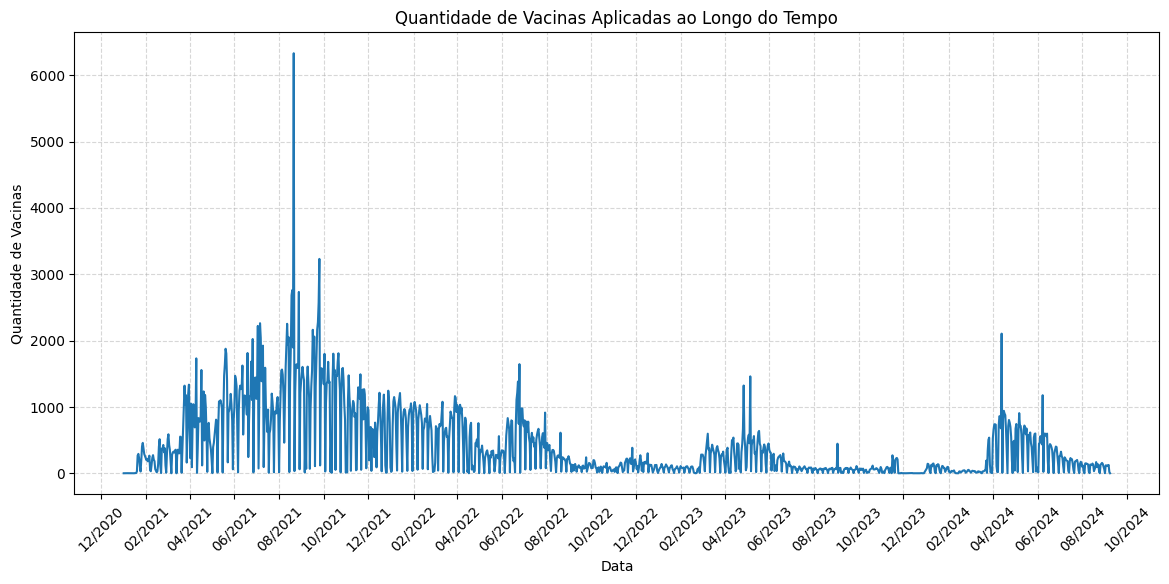

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    vacinas_por_dia.index,
    vacinas_por_dia.values
)

plt.title('Quantidade de Vacinas Aplicadas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade de Vacinas')

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%m/%Y')
)

plt.xticks(rotation=45)

plt.grid(linestyle='--', alpha=0.5)

plt.show()

### Interpretação do Gráfico Temporal

O gráfico temporal permitiu visualizar a evolução da campanha de vacinação contra a COVID-19 ao longo do tempo.

Foi possível identificar períodos de maior intensidade na aplicação das vacinas, especialmente durante os anos iniciais da campanha, além de oscilações e reduções graduais na quantidade de aplicações nos períodos posteriores.

Os picos observados no gráfico podem estar relacionados a campanhas de reforço, ampliação das faixas etárias elegíveis e períodos de maior mobilização da vacinação.

### Quantidade de Vacinas por Fabricante

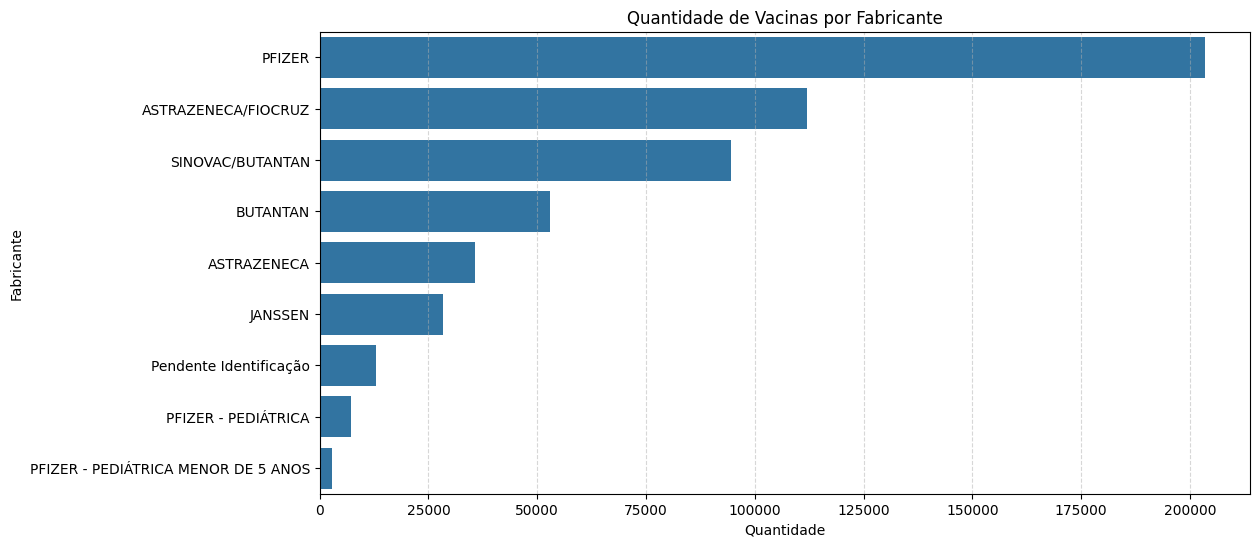

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_limpo,
    y='vacina_fabricante_nome',
    order=df_limpo['vacina_fabricante_nome']
        .value_counts()
        .index
)

plt.title('Quantidade de Vacinas por Fabricante')
plt.xlabel('Quantidade')
plt.ylabel('Fabricante')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

### Interpretação do Gráfico de Fabricantes

O gráfico apresentou a distribuição da quantidade de aplicações por fabricante das vacinas contra a COVID-19.

Foi possível observar predominância da vacina da Pfizer, seguida pelas vacinas AstraZeneca/Fiocruz e Sinovac/Butantan, demonstrando maior participação dessas fabricantes durante a campanha de vacinação.

Também foram identificadas categorias relacionadas a versões pediátricas das vacinas, além de alguns registros classificados como “Pendente Identificação”, indicando informações incompletas no dataset.

## 7. Identificação de Padrões e Correlações

Nesta etapa foram analisadas possíveis relações entre variáveis do dataset, buscando identificar tendências, padrões e comportamentos relevantes nos dados relacionados à vacinação contra a COVID-19.

### Heatmap de Correlação

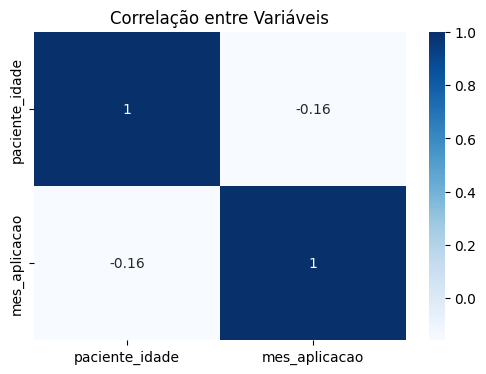

In [13]:
correlacao = df_limpo[['paciente_idade', 'mes_aplicacao']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='Blues'
)

plt.title('Correlação entre Variáveis')

plt.show()

### Interpretação do Heatmap

O heatmap apresentou a correlação entre a idade dos pacientes e o mês de aplicação das vacinas.

Foi identificada uma correlação negativa fraca (-0,16), indicando que pacientes mais idosos tenderam a receber a vacina em períodos anteriores da campanha, enquanto faixas etárias mais jovens passaram a aparecer com maior frequência nos meses posteriores.

Esse comportamento está relacionado à estratégia de vacinação adotada durante a pandemia, priorizando inicialmente grupos de maior risco, como idosos.

## 8. Identificação de Outliers

Nesta etapa foram identificados possíveis valores extremos relacionados à idade dos pacientes vacinados.

Para isso, foi utilizado o método do Intervalo Interquartil (IQR), amplamente utilizado em análises estatísticas para detectar outliers.

In [14]:
Q1 = idades.quantile(0.25)
Q3 = idades.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = idades[
    (idades < limite_inferior) |
    (idades > limite_superior)
]

print("Quantidade de outliers:", len(outliers))
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Quantidade de outliers: 10
Limite inferior: -23.5
Limite superior: 108.5


### Interpretação dos Outliers

A análise identificou 10 possíveis outliers relacionados a pacientes com idades acima do limite superior calculado pelo método IQR.

Os valores extremos encontrados correspondem a pacientes muito idosos, acima de aproximadamente 108 anos. Apesar de incomuns, esses registros foram mantidos no dataset por representarem valores plausíveis em uma base de dados nacional de vacinação.

A baixa quantidade de outliers indica que os dados apresentam boa consistência em relação à distribuição das idades.

## 9. Criação de KPIs

Nesta etapa foram criados indicadores (KPIs) com o objetivo de resumir informações importantes do dataset e auxiliar na interpretação dos dados relacionados à vacinação contra a COVID-19.

### KPI 1 — Total de Vacinas Aplicadas

In [15]:
total_vacinas = len(df_limpo)

print("Total de vacinas aplicadas:", total_vacinas)

Total de vacinas aplicadas: 549881


Este indicador representa a quantidade total de registros válidos presentes no dataset após o tratamento dos dados.

O KPI demonstra o volume de aplicações analisadas no projeto, permitindo compreender a dimensão da base utilizada.

### KPI 2 — Média de Idade dos Pacientes

In [16]:
media_idade = df_limpo['paciente_idade'].mean()

print("Média de idade:", round(media_idade, 2))

Média de idade: 42.14


Este indicador apresenta a média de idade dos pacientes vacinados presentes no dataset.

O resultado demonstra que a maior parte dos registros está concentrada em pacientes adultos, com média aproximada de 42 anos.

### KPI 3 — Fabricante Mais Utilizado


In [17]:
fabricante_mais_usado = (
    df_limpo['vacina_fabricante_nome']
    .value_counts()
    .idxmax()
)

print("Fabricante mais utilizado:", fabricante_mais_usado)

Fabricante mais utilizado: PFIZER


Este indicador identifica o fabricante com maior quantidade de aplicações registradas no dataset.

O resultado demonstrou que a Pfizer foi o fabricante mais utilizado entre os registros analisados, indicando forte participação da vacina durante a campanha de vacinação contra a COVID-19.

Esse KPI permite compreender quais fabricantes tiveram maior presença na aplicação das vacinas ao longo do período analisado.

### KPI 4 — Mês com Maior Quantidade de Vacinações


In [18]:
mes_mais_vacinacao = (
    df_limpo['mes_aplicacao']
    .value_counts()
    .idxmax()
)

print("Mês com mais vacinações:", mes_mais_vacinacao)

Mês com mais vacinações: 6


Este indicador identifica o mês que apresentou a maior quantidade de aplicações registradas no dataset.

O resultado demonstrou que o mês 6 (junho) apresentou o maior volume de vacinações, indicando um período de maior intensidade da campanha de vacinação contra a COVID-19.

Esse KPI permite identificar períodos de maior mobilização da vacinação e compreender o comportamento temporal das aplicações ao longo da campanha.

# 10. Conclusão

A análise exploratória dos dados de vacinação contra a COVID-19 permitiu identificar padrões importantes relacionados ao comportamento da campanha de vacinação ao longo do tempo.

Os resultados demonstraram predominância de pacientes adultos no dataset, além de evidenciar que grupos mais idosos foram vacinados prioritariamente nos períodos iniciais da campanha.

Também foi possível identificar diferenças relevantes entre fabricantes das vacinas, com destaque para a Pfizer, que apresentou maior quantidade de aplicações registradas.

A utilização de gráficos, medidas estatísticas, análise temporal e identificação de outliers contribuiu para uma melhor compreensão dos dados e demonstrou a importância do processo de tratamento e análise em projetos de ciência de dados.

Por fim, o projeto possibilitou a aplicação prática dos conceitos estudados no Bloco 4, utilizando Python e ferramentas de análise de dados no Google Colab.